# Quadratic Solitons in PPLN Waveguides

Temporal soliton formation mediated by **χ⁽²⁾ nonlinearity** in a PPLN
waveguide. No new physics terms — quadratic solitons emerge naturally from
the coupled FH/SH dynamics that SNOW already models.

**Operating regime:** FH at 2000 nm, SH generated at 1000 nm, with a
**deliberate phase mismatch** Δk (poling period detuned from perfect QPM).
The χ⁽²⁾ interaction creates a nonlinear phase shift on the FH that can
balance anomalous GVD, supporting self-trapped pulse propagation.

**Why the quadratic regime?** The "clean" cascaded-Kerr soliton (SH
perturbative, effective NLSE) requires z₀ = T₀²/|β₂| shorter than the
crystal length AND walk-off length L_w > coherence length L_coh. In TFLN
waveguides, these constraints are mutually exclusive — the accessible
regime is genuinely quadratic, with 10–60% of energy in the SH.

In [1]:
import numpy as np
from numpy.fft import fft, ifft, fftfreq, fftshift
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.constants import pi, c, epsilon_0
from IPython.display import display

import snow
from snow import waveguides, pulses, materials, util

nm = 1e-9
um = 1e-6
mm = 1e-3
fs = 1e-15
ps = 1e-12
pJ = 1e-12

## Cell 0 — Dispersion and Regime Landscape

The three-way tension that determines the operating point:
- **Short pulses** for visible soliton dynamics (z₀ < L)
- **Long pulses** for intact cascading (walk-off length L_w > coherence length L_coh)
- **Moderate Δk** for reasonable soliton power

In TFLN waveguides, these leave the genuinely quadratic regime as the
only accessible operating point.

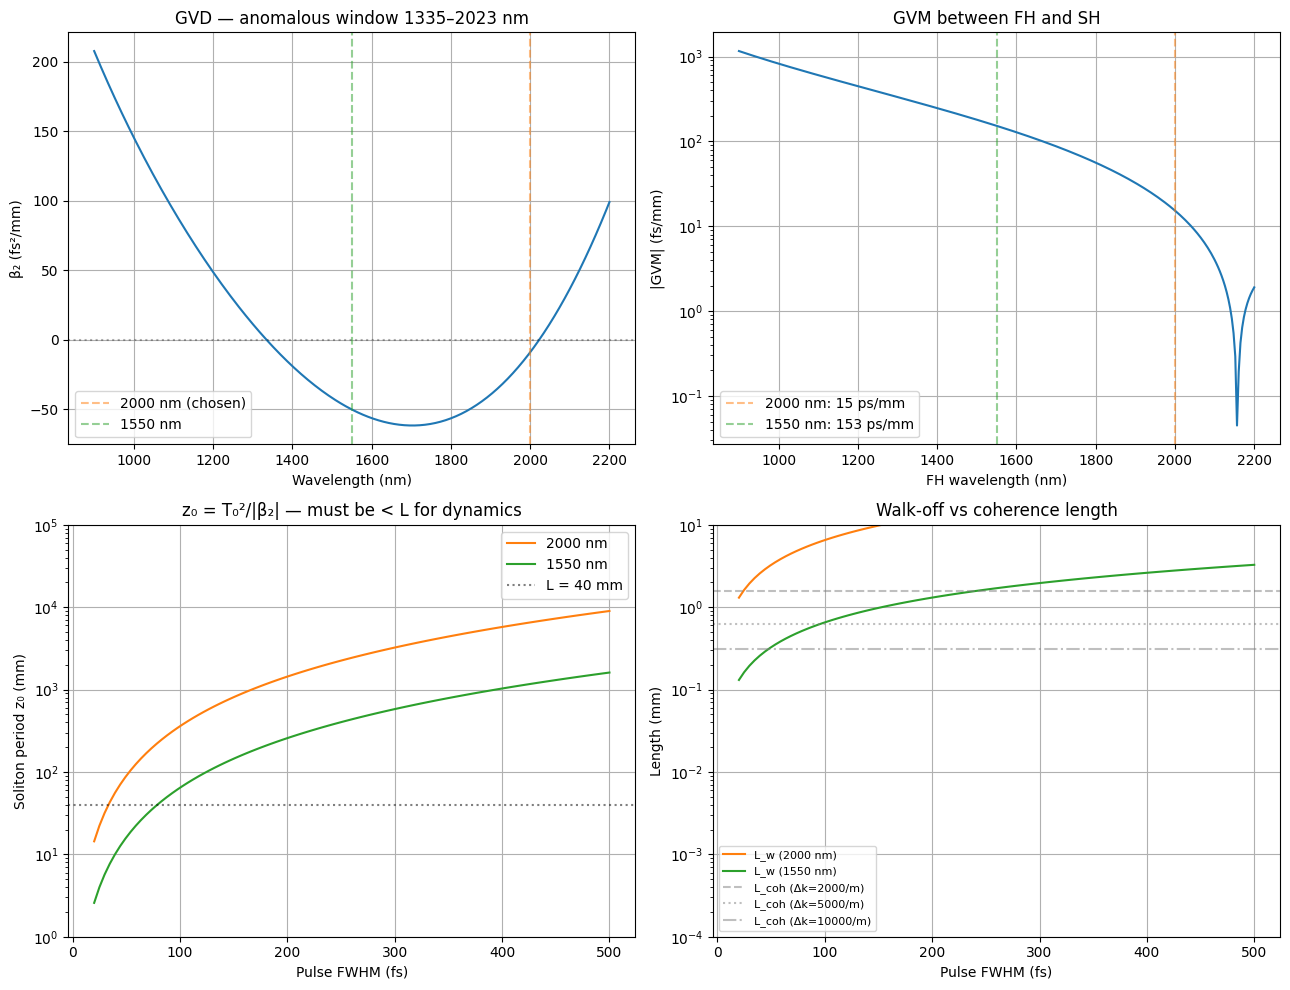

At 2000 nm: β₂ = -9.0 fs²/mm, GVM = 0.0 ps/mm
At 1550 nm: β₂ = -50.1 fs²/mm, GVM = 0.2 ps/mm


In [2]:
# Waveguide — same geometry as Tutorials 5–10
wg = waveguides.waveguide(
    w_top=1800*nm, h_thinfilm=700*nm, h_etch=350*nm,
    tf_material='LN_MgO_e_T',
    box_material='SiO2', clad_material='Air')

wl_range = np.linspace(900, 2200, 300) * nm

# GVD
gvd = np.array([wg.beta2(wl)[0] for wl in wl_range])

# GVM between FH and SH = FH/2
gvm = np.array([wg.beta1(wl)[0] - wg.beta1(wl/2)[0] for wl in wl_range])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Plot A: β₂ vs wavelength
ax = axes[0, 0]
ax.plot(wl_range/nm, gvd * 1e27)  # fs²/mm
ax.axhline(0, color='k', ls=':', alpha=0.3)
ax.axvline(2000, color='C1', ls='--', alpha=0.5, label='2000 nm (chosen)')
ax.axvline(1550, color='C2', ls='--', alpha=0.5, label='1550 nm')
ax.set_xlabel('Wavelength (nm)'); ax.set_ylabel('β₂ (fs²/mm)')
ax.set_title('GVD — anomalous window 1335–2023 nm')
ax.legend(); ax.grid(True)

# Plot B: GVM between FH and SH
ax = axes[0, 1]
ax.semilogy(wl_range/nm, np.abs(gvm) / (fs/mm))
ax.axvline(2000, color='C1', ls='--', alpha=0.5, label='2000 nm: 15 ps/mm')
ax.axvline(1550, color='C2', ls='--', alpha=0.5, label='1550 nm: 153 ps/mm')
ax.set_xlabel('FH wavelength (nm)'); ax.set_ylabel('|GVM| (fs/mm)')
ax.set_title('GVM between FH and SH')
ax.legend(); ax.grid(True)

# Plot C: Soliton period vs pulse FWHM
ax = axes[1, 0]
fwhm_range = np.linspace(20, 500, 100) * fs
for lam, col, lbl in [(2000*nm, 'C1', '2000 nm'), (1550*nm, 'C2', '1550 nm')]:
    b2 = abs(wg.beta2(lam)[0])
    T0 = fwhm_range / 1.76
    z0 = T0**2 / b2
    ax.semilogy(fwhm_range/fs, z0/mm, color=col, label=lbl)
ax.axhline(40, color='k', ls=':', alpha=0.5, label='L = 40 mm')
ax.set_xlabel('Pulse FWHM (fs)'); ax.set_ylabel('Soliton period z₀ (mm)')
ax.set_title('z₀ = T₀²/|β₂| — must be < L for dynamics')
ax.legend(); ax.grid(True); ax.set_ylim(1, 1e5)

# Plot D: Walk-off length vs pulse FWHM, with coherence lengths
ax = axes[1, 1]
for lam, col, lbl in [(2000*nm, 'C1', '2000 nm'), (1550*nm, 'C2', '1550 nm')]:
    gvm_val = abs(wg.beta1(lam)[0] - wg.beta1(lam/2)[0])
    Lw = fwhm_range / gvm_val
    ax.semilogy(fwhm_range/fs, Lw/mm, color=col, label=f'L_w ({lbl})')
for dk_val, ls in [(2000, '--'), (5000, ':'), (10000, '-.')]:  
    Lcoh = pi / dk_val
    ax.axhline(Lcoh/mm, color='gray', ls=ls, alpha=0.5,
               label=f'L_coh (Δk={dk_val}/m)')
ax.set_xlabel('Pulse FWHM (fs)'); ax.set_ylabel('Length (mm)')
ax.set_title('Walk-off vs coherence length')
ax.legend(fontsize=8); ax.grid(True); ax.set_ylim(1e-4, 10)

plt.tight_layout()
plt.show()

print('At 2000 nm: β₂ = %.1f fs²/mm, GVM = %.1f ps/mm' %
      (wg.beta2(2*um)[0]*1e27, abs(wg.beta1(2*um)[0]-wg.beta1(1*um)[0])/(ps/mm)))
print('At 1550 nm: β₂ = %.1f fs²/mm, GVM = %.1f ps/mm' %
      (wg.beta2(1550*nm)[0]*1e27, abs(wg.beta1(1550*nm)[0]-wg.beta1(775*nm)[0])/(ps/mm)))

In [3]:
# --- Simulation setup ---

N = 2**12  # 4096
lam_start, lam_stop = 900*nm, 2.5*um
BW = c/lam_start - c/lam_stop
dt = 1/BW
t = np.arange(N)*dt - N*dt/2
f_ref = (c/lam_start + c/lam_stop)/2
f_abs = fftfreq(N, dt) + f_ref

# Poling period from Tutorial 7 (designed for 2000nm SHG near T≈0°C)
pp = 5.18 * um
Kg = 2*pi / pp

# Operating temperature: T=25°C gives Δk ≈ 1785/m (quadratic regime)
T_op = 25.0
n_fh = wg.neff(2*um, T=T_op)[0]
n_sh = wg.neff(1*um, T=T_op)[0]
dk = 2*pi*n_sh/(1*um) - 2*2*pi*n_fh/(2*um) - Kg

# Carrier-phase-minimizing v_ref
beta_ref_val = wg.beta(np.array([c/f_ref]), T=T_op)[0]
v_ref = 2*pi*f_ref / (beta_ref_val + Kg)

# Waveguide setup
X0 = 1.1e-12
L = 40 * mm

def poling_Kg(z): return 1.0
wg.add_poling(poling_Kg)
wg.set_nonlinear_coeffs(N=1, X0=X0)
wg.set_length(L)
wg.set_loss(0)

# FH/SH spectral separation at 1200nm
f_sep = c / (1200*nm)
mask_fh = f_abs < f_sep
mask_sh = f_abs >= f_sep

def separate_fh_sh(field):
    """Split field into FH (>1200nm) and SH (<1200nm) components."""
    A = fft(field)
    a_fh = ifft(A * mask_fh)
    a_sh = ifft(A * mask_sh)
    return a_fh, a_sh

print(f'Grid: N={N}, λ range: {c/np.max(f_abs)/nm:.0f}–{c/np.min(f_abs[f_abs>0])/nm:.0f} nm')
print(f'Δk = {dk:.0f} /m, Δk·L = {dk*L:.0f}')
print(f'Phase matching (Δk=0) near T ≈ 0°C')

Grid: N=4096, λ range: 900–2500 nm
Δk = 1785 /m, Δk·L = 71
Phase matching (Δk=0) near T ≈ 0°C


## Cell 1 — Two-Color Quadratic Soliton Dynamics

100 fs sech pulse at 2000 nm, energy scan from 0.5–15 pJ.
At moderate energy, the FH self-traps and the SH becomes a
co-propagating bound partner carrying 30–60% of the total energy.

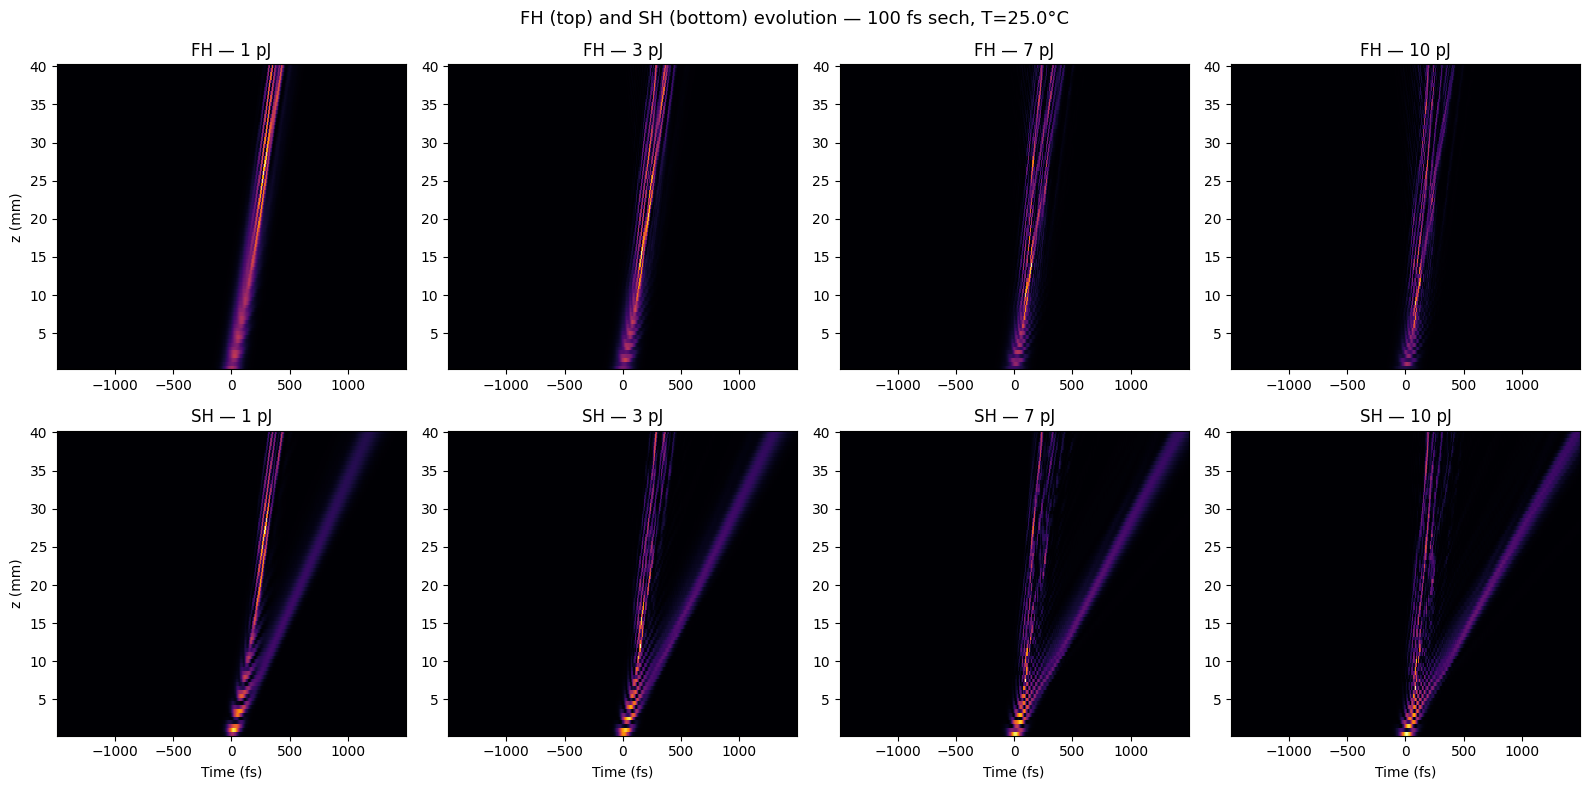

/home/soul/Projects/snow/snow/waveguides.py:310: UserWarning: Large bandwidth requires 8x upsampling.
  [a, a_evol] = nlo.NEE(**nee_args, z_save=z_save)


  E = 1 pJ done
  E = 3 pJ done
  E = 7 pJ done
  E = 10 pJ done


In [4]:
# --- z-t evolution maps at several energies ---

FWHM = 100 * fs
z_pos = np.linspace(0.5*mm, L, 80)
energies = [1, 3, 7, 10]  # pJ

fig, axes = plt.subplots(2, len(energies), figsize=(4*len(energies), 8))
fig.suptitle(f'FH (top) and SH (bottom) evolution — {FWHM/fs:.0f} fs sech, T={T_op}°C',
             fontsize=13)
fig_handle = display(fig, display_id=True)
plt.ion()

t_win = 1.5 * ps  # time window for plotting
t_mask = np.abs(t) < t_win
t_plot = t[t_mask] / fs

for ie, E_pJ in enumerate(energies):
    p = pulses.sech_pulse(t, FWHM, f_ref=f_ref, Energy=E_pJ*pJ,
                          f0=c/(2*um), Npwr_dB=200, frep=250e6)
    out, snaps = wg.propagate_NEE(p, v_ref=v_ref, verbose=False,
                                  T=T_op, Kg=Kg, z_save=z_pos)

    # Build (z, t) maps for FH and SH
    I_fh = np.zeros((len(z_pos), np.sum(t_mask)))
    I_sh = np.zeros_like(I_fh)
    for iz in range(len(z_pos)):
        a_fh, a_sh = separate_fh_sh(snaps[iz])
        I_fh[iz] = np.abs(a_fh[t_mask])**2
        I_sh[iz] = np.abs(a_sh[t_mask])**2

    vmax_fh = np.max(I_fh)
    vmax_sh = np.max(I_sh)

    axes[0, ie].pcolormesh(t_plot, z_pos/mm, I_fh,
                           shading='auto', cmap='inferno', vmin=0, vmax=vmax_fh)
    axes[0, ie].set_title(f'FH — {E_pJ} pJ')
    axes[0, ie].set_ylabel('z (mm)') if ie == 0 else None

    axes[1, ie].pcolormesh(t_plot, z_pos/mm, I_sh,
                           shading='auto', cmap='inferno', vmin=0, vmax=vmax_sh)
    axes[1, ie].set_title(f'SH — {E_pJ} pJ')
    axes[1, ie].set_xlabel('Time (fs)')
    axes[1, ie].set_ylabel('z (mm)') if ie == 0 else None

    fig_handle.update(fig)
    print(f'  E = {E_pJ} pJ done')

plt.tight_layout()
fig_handle.update(fig)
plt.close(fig)

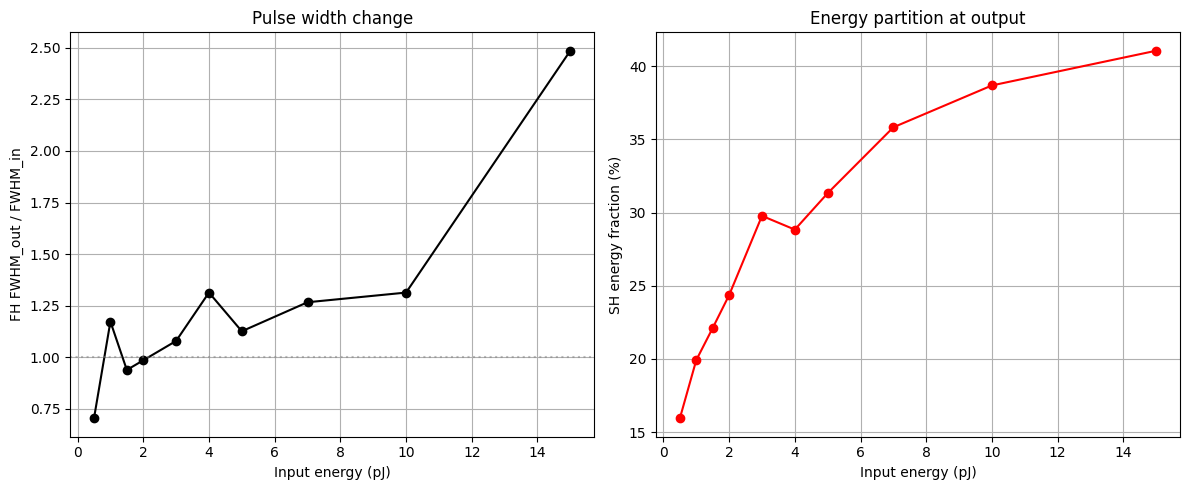

In [5]:
# --- Output pulse width and SH fraction vs energy ---

E_scan = np.array([0.5, 1, 1.5, 2, 3, 4, 5, 7, 10, 15]) * pJ
fwhm_ratios = []
sh_fractions = []

for E in E_scan:
    p = pulses.sech_pulse(t, FWHM, f_ref=f_ref, Energy=E,
                          f0=c/(2*um), Npwr_dB=200, frep=250e6)
    out, _ = wg.propagate_NEE(p, v_ref=v_ref, verbose=False,
                              T=T_op, Kg=Kg)
    # FH FWHM
    a_fh, a_sh = separate_fh_sh(out.a)
    I_fh = np.abs(a_fh)**2
    halfmax = np.max(I_fh) / 2
    above = np.where(I_fh > halfmax)[0]
    fwhm_out = (t[above[-1]] - t[above[0]]) if len(above) > 1 else float('nan')
    fwhm_ratios.append(fwhm_out / FWHM)

    # SH energy fraction
    E_fh = np.sum(np.abs(a_fh)**2) * dt
    E_sh = np.sum(np.abs(a_sh)**2) * dt
    sh_fractions.append(E_sh / (E_fh + E_sh))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(E_scan/pJ, fwhm_ratios, 'ko-')
ax1.axhline(1, color='gray', ls=':', alpha=0.5)
ax1.set_xlabel('Input energy (pJ)'); ax1.set_ylabel('FH FWHM_out / FWHM_in')
ax1.set_title('Pulse width change')
ax1.grid(True)

ax2.plot(E_scan/pJ, np.array(sh_fractions)*100, 'ro-')
ax2.set_xlabel('Input energy (pJ)'); ax2.set_ylabel('SH energy fraction (%)')
ax2.set_title('Energy partition at output')
ax2.grid(True)

plt.tight_layout()
plt.show()

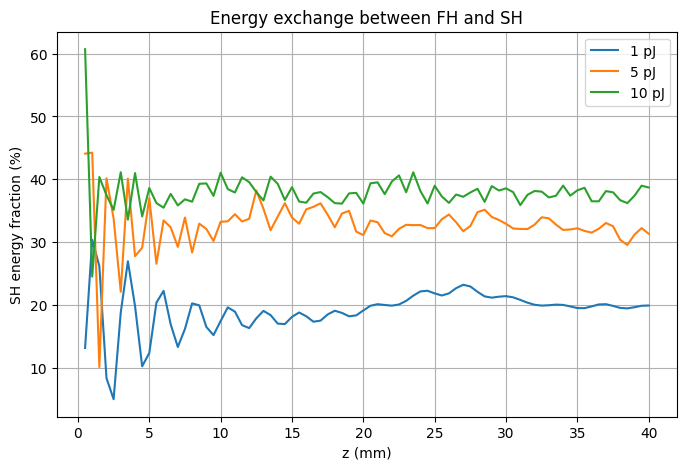

In [6]:
# --- FH/SH energy exchange along z ---

z_pos_fine = np.linspace(0.5*mm, L, 80)
E_demo = [1, 5, 10]  # pJ

fig, ax = plt.subplots(figsize=(8, 5))
for E_pJ in E_demo:
    p = pulses.sech_pulse(t, FWHM, f_ref=f_ref, Energy=E_pJ*pJ,
                          f0=c/(2*um), Npwr_dB=200, frep=250e6)
    out, snaps = wg.propagate_NEE(p, v_ref=v_ref, verbose=False,
                                  T=T_op, Kg=Kg, z_save=z_pos_fine)
    sh_frac_z = []
    for iz in range(len(z_pos_fine)):
        a_fh, a_sh = separate_fh_sh(snaps[iz])
        E_sh = np.sum(np.abs(a_sh)**2) * dt
        E_tot = np.sum(np.abs(snaps[iz])**2) * dt
        sh_frac_z.append(E_sh / E_tot * 100)
    ax.plot(z_pos_fine/mm, sh_frac_z, label=f'{E_pJ} pJ')

ax.set_xlabel('z (mm)'); ax.set_ylabel('SH energy fraction (%)')
ax.set_title('Energy exchange between FH and SH')
ax.legend(); ax.grid(True)
plt.show()

## Cell 2 — Velocity Locking

The signature property of the quadratic soliton: the nonlinear coupling
forces FH and SH to co-propagate at the **same** group velocity, despite
having different free-propagation velocities (GVM ≈ 15 ps/mm at 2000/1000 nm).

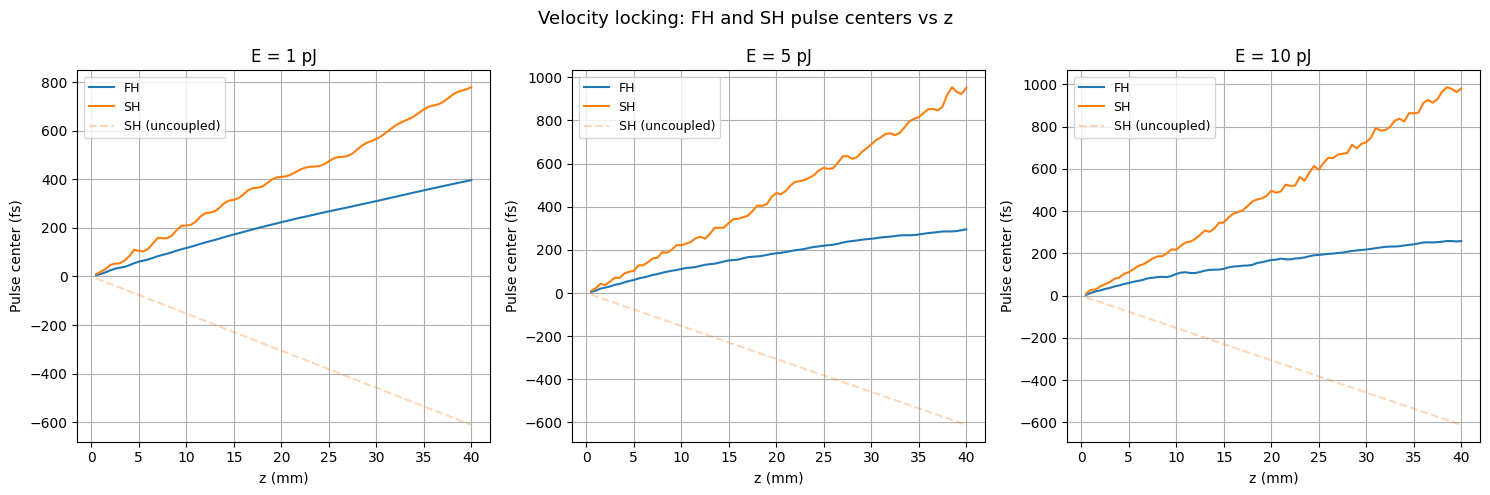

  E = 1 pJ done
  E = 5 pJ done
  E = 10 pJ done


In [7]:
# Track pulse center of mass for FH and SH along z

E_lock = [1, 5, 10]  # pJ — below, near, and above soliton threshold

fig, axes = plt.subplots(1, len(E_lock), figsize=(5*len(E_lock), 5))
fig_handle = display(fig, display_id=True)
plt.ion()

gvm_val = float(wg.beta1(2*um, T=T_op)[0] - wg.beta1(1*um, T=T_op)[0])

for ie, E_pJ in enumerate(E_lock):
    p = pulses.sech_pulse(t, FWHM, f_ref=f_ref, Energy=E_pJ*pJ,
                          f0=c/(2*um), Npwr_dB=200, frep=250e6)
    out, snaps = wg.propagate_NEE(p, v_ref=v_ref, verbose=False,
                                  T=T_op, Kg=Kg, z_save=z_pos)

    fh_centers, sh_centers = [], []
    for iz in range(len(z_pos)):
        a_fh, a_sh = separate_fh_sh(snaps[iz])
        I_fh = np.abs(a_fh)**2
        I_sh = np.abs(a_sh)**2
        fh_centers.append(np.sum(t * I_fh) / np.sum(I_fh))
        if np.sum(I_sh) > 0:
            sh_centers.append(np.sum(t * I_sh) / np.sum(I_sh))
        else:
            sh_centers.append(np.nan)

    ax = axes[ie]
    ax.plot(z_pos/mm, np.array(fh_centers)/fs, 'C0-', label='FH')
    ax.plot(z_pos/mm, np.array(sh_centers)/fs, 'C1-', label='SH')

    # Reference: linear (uncoupled) trajectories
    # In v_ref frame, FH drifts at (1/vg_FH - 1/v_ref) and SH at (1/vg_SH - 1/v_ref)
    ax.plot(z_pos/mm, gvm_val * z_pos / fs, 'C1--', alpha=0.3,
            label='SH (uncoupled)')

    ax.set_xlabel('z (mm)'); ax.set_ylabel('Pulse center (fs)')
    ax.set_title(f'E = {E_pJ} pJ')
    ax.legend(fontsize=9); ax.grid(True)
    fig_handle.update(fig)
    print(f'  E = {E_pJ} pJ done')

plt.suptitle('Velocity locking: FH and SH pulse centers vs z', fontsize=13)
plt.tight_layout()
fig_handle.update(fig)
plt.close(fig)

## Cell 3 — Energy–Δk Phase Diagram

Sweep temperature (Δk) and input energy on a 2D grid. Classify each point
by FH pulse width change and SH energy fraction. The soliton existence
region is the boundary between compression and broadening.

**This runs ~200 simulations (~15 min). Each column updates the plot live.**

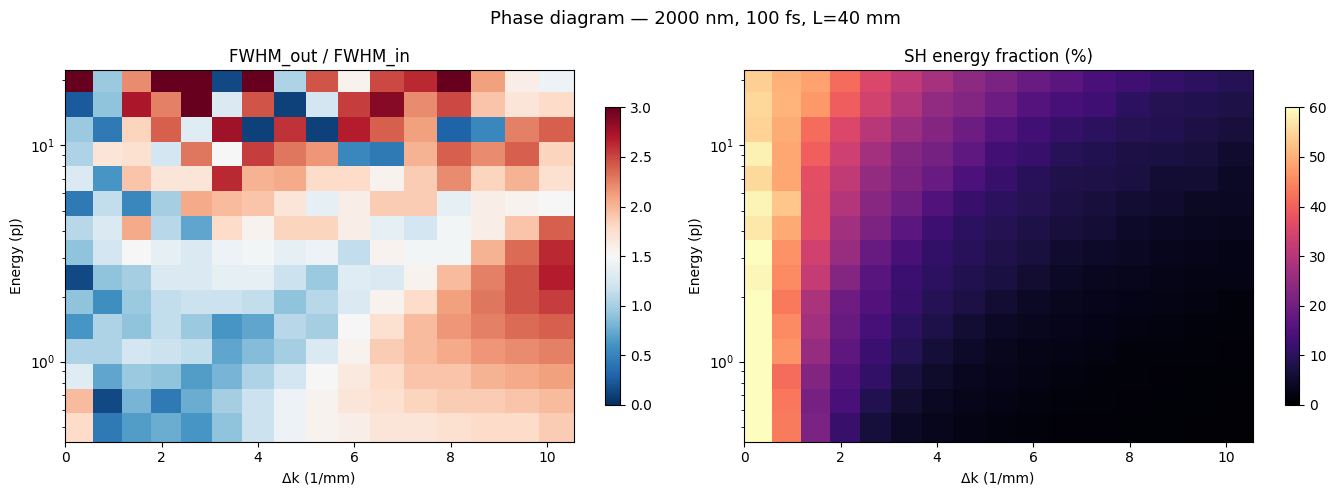

  T=5°C (Δk=282/m) done
  T=13°C (Δk=874/m) done
  T=21°C (Δk=1478/m) done
  T=29°C (Δk=2094/m) done
  T=37°C (Δk=2719/m) done
  T=45°C (Δk=3356/m) done
  T=53°C (Δk=4002/m) done
  T=61°C (Δk=4657/m) done
  T=69°C (Δk=5322/m) done
  T=77°C (Δk=5995/m) done
  T=85°C (Δk=6677/m) done
  T=93°C (Δk=7367/m) done
  T=101°C (Δk=8064/m) done
  T=109°C (Δk=8768/m) done
  T=117°C (Δk=9479/m) done
  T=125°C (Δk=10196/m) done


In [8]:
# Temperature (Δk) and energy grid
T_grid = np.arange(5, 130, 8)  # °C
E_grid = np.logspace(-0.3, 1.3, 15) * pJ  # ~0.5 to 20 pJ

# Compute Δk for each temperature
dk_grid = []
for T in T_grid:
    n_fh = wg.neff(2*um, T=T)[0]
    n_sh = wg.neff(1*um, T=T)[0]
    dk_grid.append(2*pi*n_sh/(1*um) - 2*2*pi*n_fh/(2*um) - Kg)
dk_grid = np.array(dk_grid)

fwhm_map = np.full((len(T_grid), len(E_grid)), np.nan)
sh_map = np.full_like(fwhm_map, np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig_handle = display(fig, display_id=True)
plt.ion()

for iT, T_val in enumerate(T_grid):
    # Recompute v_ref for this temperature
    beta_ref_T = wg.beta(np.array([c/f_ref]), T=T_val)[0]
    v_ref_T = 2*pi*f_ref / (beta_ref_T + Kg)

    for iE, E_val in enumerate(E_grid):
        p = pulses.sech_pulse(t, FWHM, f_ref=f_ref, Energy=E_val,
                              f0=c/(2*um), Npwr_dB=200, frep=250e6)
        out, _ = wg.propagate_NEE(p, v_ref=v_ref_T, verbose=False,
                                  T=T_val, Kg=Kg)
        a_fh, a_sh = separate_fh_sh(out.a)
        I_fh = np.abs(a_fh)**2
        halfmax = np.max(I_fh) / 2
        above = np.where(I_fh > halfmax)[0]
        if len(above) > 1:
            fwhm_out = t[above[-1]] - t[above[0]]
            fwhm_map[iT, iE] = fwhm_out / FWHM
        E_fh = np.sum(np.abs(a_fh)**2) * dt
        E_sh = np.sum(np.abs(a_sh)**2) * dt
        sh_map[iT, iE] = E_sh / (E_fh + E_sh) * 100

    # Update plot after each temperature column
    for ax in [ax1, ax2]:
        ax.clear()
    im1 = ax1.pcolormesh(dk_grid/1e3, E_grid/pJ, fwhm_map.T,
                          shading='auto', cmap='RdBu_r', vmin=0, vmax=3)
    ax1.set_xlabel('Δk (1/mm)'); ax1.set_ylabel('Energy (pJ)')
    ax1.set_yscale('log'); ax1.set_title('FWHM_out / FWHM_in')

    im2 = ax2.pcolormesh(dk_grid/1e3, E_grid/pJ, sh_map.T,
                          shading='auto', cmap='magma', vmin=0, vmax=60)
    ax2.set_xlabel('Δk (1/mm)'); ax2.set_ylabel('Energy (pJ)')
    ax2.set_yscale('log'); ax2.set_title('SH energy fraction (%)')

    fig_handle.update(fig)
    print(f'  T={T_val:.0f}°C (Δk={dk_grid[iT]:.0f}/m) done')

fig.colorbar(im1, ax=ax1, shrink=0.8)
fig.colorbar(im2, ax=ax2, shrink=0.8)
plt.suptitle(f'Phase diagram — 2000 nm, {FWHM/fs:.0f} fs, L={L/mm:.0f} mm', fontsize=13)
plt.tight_layout()
fig_handle.update(fig)
plt.close(fig)

## Cell 4 — Soliton Self-Compression and Spectral Broadening

Push to high energy (3–5× threshold) for higher-order soliton compression
followed by fission and dispersive wave emission — the χ⁽²⁾ analog of
supercontinuum-generating soliton fission in fiber.

**Irony:** The FDTD SHG work fought to eliminate parasitic Δk from numerical
dispersion. Here we use physical Δk as the mechanism for pulse self-trapping.
Same interaction, opposite goals.

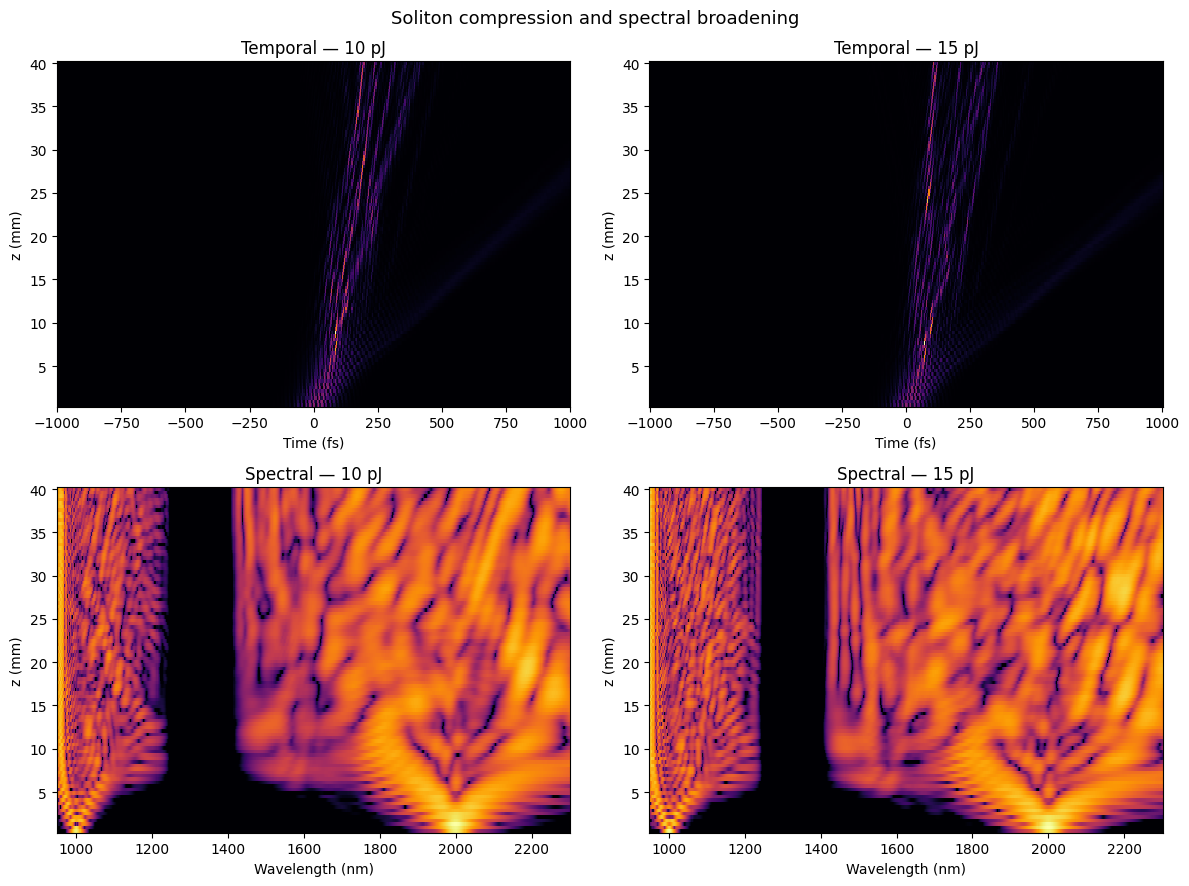

  E = 10 pJ done
  E = 15 pJ done


In [9]:
# High-energy compression: 3× and 5× the threshold energy
E_high = [10, 15]  # pJ
z_pos_dense = np.linspace(0.5*mm, L, 100)

fig, axes = plt.subplots(2, len(E_high), figsize=(6*len(E_high), 9))
fig_handle = display(fig, display_id=True)
plt.ion()

for ie, E_pJ in enumerate(E_high):
    p = pulses.sech_pulse(t, FWHM, f_ref=f_ref, Energy=E_pJ*pJ,
                          f0=c/(2*um), Npwr_dB=200, frep=250e6)
    out, snaps = wg.propagate_NEE(p, v_ref=v_ref, verbose=False,
                                  T=T_op, Kg=Kg, z_save=z_pos_dense)

    # z-t map (total field)
    t_win_comp = 1 * ps
    t_mask_c = np.abs(t) < t_win_comp
    I_zt = np.array([np.abs(snaps[iz][t_mask_c])**2 for iz in range(len(z_pos_dense))])

    axes[0, ie].pcolormesh(t[t_mask_c]/fs, z_pos_dense/mm, I_zt,
                           shading='auto', cmap='inferno')
    axes[0, ie].set_xlabel('Time (fs)'); axes[0, ie].set_ylabel('z (mm)')
    axes[0, ie].set_title(f'Temporal — {E_pJ} pJ')

    # z-λ map (spectrum evolution)
    wl_plot = np.linspace(950, 2300, 500) * nm
    spec_zt = np.zeros((len(z_pos_dense), len(wl_plot)))
    for iz in range(len(z_pos_dense)):
        A = fft(snaps[iz])
        psd = np.abs(A)**2 * dt**2
        spec_zt[iz] = np.interp(c/wl_plot, fftshift(f_abs), fftshift(psd))

    spec_zt_norm = spec_zt / np.max(spec_zt)
    axes[1, ie].pcolormesh(wl_plot/nm, z_pos_dense/mm,
                           10*np.log10(spec_zt_norm + 1e-10),
                           shading='auto', cmap='inferno', vmin=-40, vmax=0)
    axes[1, ie].set_xlabel('Wavelength (nm)'); axes[1, ie].set_ylabel('z (mm)')
    axes[1, ie].set_title(f'Spectral — {E_pJ} pJ')

    fig_handle.update(fig)
    print(f'  E = {E_pJ} pJ done')

plt.suptitle('Soliton compression and spectral broadening', fontsize=13)
plt.tight_layout()
fig_handle.update(fig)
plt.close(fig)

## Cell 5 — Summary

| Property | Quadratic soliton (this notebook) | Cascaded-Kerr (limit) | Kerr soliton (fiber) |
|---|---|---|---|
| Nonlinear mechanism | FH ↔ SH parametric coupling | Same, perturbative limit | χ⁽³⁾ SPM |
| Fields involved | FH + SH, both active | FH dominant, SH slaved | Single field |
| SH energy fraction | 10–60% | < 1% | N/A |
| Soliton shape | Non-sech (wider tails) | sech (Kerr-like) | sech |
| Velocity locking | Yes — FH and SH co-propagate | Not relevant | N/A |
| Accessible in TFLN? | **Yes** | No (needs meters of WG) | No (needs χ⁽³⁾) |
| Key parameter | Δk (via temperature) | Δk (must be large) | γ (material) |

### Key findings

1. **The cascaded-Kerr soliton is inaccessible** in practical TFLN waveguide
   lengths. z₀ = T₀²/|β₂| is hundreds of mm even for ultrashort pulses at
   2000 nm. At 1550 nm, GVM (153 ps/mm) kills the cascading mechanism.

2. **The quadratic regime IS accessible** at 2000 nm with Δk ≈ 1800/m
   (T ≈ 25°C, pp = 5.18 µm). The SH carries 30–60% of the energy and is a
   dynamically active co-propagating partner.

3. **Velocity locking** — the FH and SH pulse centers travel together despite
   15 ps/mm GVM — is the distinctive signature of the bound state.

4. **The phase diagram** (Cell 3) maps the transition from dispersive broadening
   to compression, showing where quadratic solitons exist in (Δk, energy) space.
   The cascaded-Kerr soliton line lies in the inaccessible high-Δk corner.